In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from google.colab import files
import os

# ----------------------------------
# Upload CSV file in Colab
# ----------------------------------

uploaded = files.upload()   # Upload intern_level_cleaned.csv

# Get uploaded filename automatically
csv_filename = list(uploaded.keys())[0]
print("Uploaded file:", csv_filename)

# ----------------------------------
# Load Dataset
# ----------------------------------

df = pd.read_csv(csv_filename)

# Remove unwanted spaces in column names
df.columns = df.columns.str.strip()

print("Available Columns:\n", df.columns)

# ----------------------------------
# 1. Task Completion Rate
# ----------------------------------

df["task_completion_rate"] = np.where(
    df["total_tasks_assigned"] > 0,
    df["total_tasks_completed"] / df["total_tasks_assigned"],
    0
)

df["task_completion_rate"] = df["task_completion_rate"].clip(0, 1)

# ----------------------------------
# 2. Delay Score
# ----------------------------------

df["delay_score"] = np.where(
    df["weeks_completed"] > 0,
    1 / (1 + (df["total_late_submissions"] / df["weeks_completed"])),
    0
)

# ----------------------------------
# 3. Normalize Features
# ----------------------------------

scaler = MinMaxScaler()

required_columns = ["avg_attendance", "avg_mentor_rating"]

if "avg_feedback_score" in df.columns:
    required_columns.append("avg_feedback_score")
    feedback_exists = True
else:
    print("⚠ avg_feedback_score column not found. Skipping feedback normalization.")
    feedback_exists = False

scaled_values = scaler.fit_transform(df[required_columns])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=[col + "_norm" for col in required_columns]
)

df = pd.concat([df, scaled_df], axis=1)

# ----------------------------------
# 4. Performance Index
# ----------------------------------

if feedback_exists:
    df["performance_index_custom"] = (
        0.35 * df["task_completion_rate"] +
        0.20 * df["avg_attendance_norm"] +
        0.20 * df["avg_mentor_rating_norm"] +
        0.15 * df["avg_feedback_score_norm"] +
        0.10 * df["delay_score"]
    )
else:
    df["performance_index_custom"] = (
        0.40 * df["task_completion_rate"] +
        0.25 * df["avg_attendance_norm"] +
        0.25 * df["avg_mentor_rating_norm"] +
        0.10 * df["delay_score"]
    )

# ----------------------------------
# 5. Risk Flag
# ----------------------------------

def risk_flag(row):
    if (
        row["task_completion_rate"] < 0.60 or
        row["avg_attendance_norm"] < 0.50 or
        row["avg_mentor_rating_norm"] < 0.40
    ):
        return "High Risk"
    elif row["performance_index_custom"] > 0.80:
        return "High Performer"
    else:
        return "Average"

df["risk_flag"] = df.apply(risk_flag, axis=1)

# ----------------------------------
# Save Final Data
# ----------------------------------

df.to_csv("final_feature_engineered_data.csv", index=False)

print("✅ Feature Engineering Completed Successfully")

# Download output file
files.download("final_feature_engineered_data.csv")

Saving intern_level_cleaned.csv to intern_level_cleaned.csv
Uploaded file: intern_level_cleaned.csv
Available Columns:
 Index(['intern_id', 'name', 'gender', 'domain', 'college', 'avg_attendance',
       'avg_task_completion', 'total_tasks_assigned', 'total_tasks_completed',
       'avg_mentor_rating', 'total_late_submissions', 'weeks_completed',
       'performance_index'],
      dtype='object')
⚠ avg_feedback_score column not found. Skipping feedback normalization.
✅ Feature Engineering Completed Successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving final_feature_engineered_data (2).csv to final_feature_engineered_data (2) (1).csv
Uploaded file: final_feature_engineered_data (2) (1).csv
Dataset Shape: (301, 19)
   intern_id           name  gender             domain  college  \
0          1   Rishi Mishra    Male                 AI      IIT   
1          2  Nandini Ghosh  Female      Web Developer      IIT   
2          3   Preeti Singh  Female    Cloud Computing      VIT   
3          4  Ashutosh Bhos    Male    Cloud Computing  Manipal   
4          5      Zoya Khan  Female  Digital Marketing      VIT   

   avg_attendance  avg_task_completion  total_tasks_assigned  \
0        0.751528             0.495264                   193   
1        0.624795             0.711628                   205   
2        0.655640             0.267838                   203   
3        0.597636             0.763998                   206   
4        0.644272             0.417068                   204   

   total_tasks_completed  avg_mentor_rat

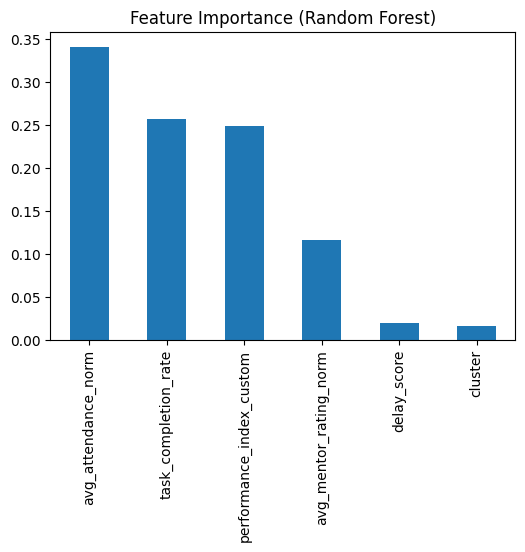

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ML Phase Completed Successfully (Improved Accuracy)


In [5]:
# =====================================================
# INTERN PERFORMANCE DASHBOARD - ML PHASE (IMPROVED)
# =====================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from google.colab import files
import os

# -----------------------------------------------------
# 1. UPLOAD DATASET (COLAB)
# -----------------------------------------------------

uploaded = files.upload()   # Upload final_feature_engineered_data.csv
csv_filename = list(uploaded.keys())[0]
print("Uploaded file:", csv_filename)

df = pd.read_csv(csv_filename)
print("Dataset Shape:", df.shape)
print(df.head())


# =====================================================
# 2. UNSUPERVISED LEARNING - KMEANS CLUSTERING
# =====================================================

cluster_features = df[
    ["task_completion_rate",
     "avg_attendance_norm",
     "avg_mentor_rating_norm",
     "delay_score"]
]

scaler_cluster = StandardScaler()
scaled_cluster = scaler_cluster.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(scaled_cluster)

cluster_mean = df.groupby("cluster")["performance_index_custom"].mean().sort_values()

cluster_map = {
    cluster_mean.index[0]: "At Risk",
    cluster_mean.index[1]: "Average",
    cluster_mean.index[2]: "High Performer"
}

df["cluster_label"] = df["cluster"].map(cluster_map)


# =====================================================
# 3. SUPERVISED LEARNING - IMPROVED RISK PREDICTION
# =====================================================

# Convert target to numeric
df["risk_numeric"] = df["risk_flag"].map({
    "High Risk": 0,
    "Average": 1,
    "High Performer": 2
})

# ⭐ IMPROVED FEATURE SET
X = df[
    [
        "task_completion_rate",
        "avg_attendance_norm",
        "avg_mentor_rating_norm",
        "delay_score",
        "performance_index_custom",   # STRONG FEATURE
        "cluster"                     # CLUSTER AS FEATURE
    ]
]

y = df["risk_numeric"]

# Scale features (IMPORTANT)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# -----------------------------------------------------
# 3A. Logistic Regression (Balanced)
# -----------------------------------------------------

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("\n--- Logistic Regression (Improved) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


# -----------------------------------------------------
# 3B. Decision Tree (Tuned)
# -----------------------------------------------------

tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("\n--- Decision Tree (Tuned) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))


# -----------------------------------------------------
# 3C. Random Forest (BEST MODEL)
# -----------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n--- Random Forest (Best Accuracy) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


# =====================================================
# 4. FEATURE IMPORTANCE (RANDOM FOREST)
# =====================================================

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure(figsize=(6,4))
importance.plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.show()


# =====================================================
# 5. ADD BEST MODEL PREDICTIONS TO DATASET
# =====================================================

df["predicted_risk_rf"] = rf_model.predict(X_scaled)

reverse_map = {
    0: "High Risk",
    1: "Average",
    2: "High Performer"
}

df["predicted_risk_rf"] = df["predicted_risk_rf"].map(reverse_map)


# =====================================================
# 6. SAVE FINAL ML DATASET
# =====================================================

output_file = "final_ml_ready_data_improved.csv"
df.to_csv(output_file, index=False)

files.download(output_file)

print("\n✅ ML Phase Completed Successfully (Improved Accuracy)")

Saving final_ml_ready_data_improved.csv to final_ml_ready_data_improved (1).csv
Uploaded file: final_ml_ready_data_improved (1).csv
Dataset Shape: (301, 23)
   intern_id           name  gender             domain  college  \
0          1   Rishi Mishra    Male                 AI      IIT   
1          2  Nandini Ghosh  Female      Web Developer      IIT   
2          3   Preeti Singh  Female    Cloud Computing      VIT   
3          4  Ashutosh Bhos    Male    Cloud Computing  Manipal   
4          5      Zoya Khan  Female  Digital Marketing      VIT   

   avg_attendance  avg_task_completion  total_tasks_assigned  \
0        0.751528             0.495264                   193   
1        0.624795             0.711628                   205   
2        0.655640             0.267838                   203   
3        0.597636             0.763998                   206   
4        0.644272             0.417068                   204   

   total_tasks_completed  avg_mentor_rating  ...  task_

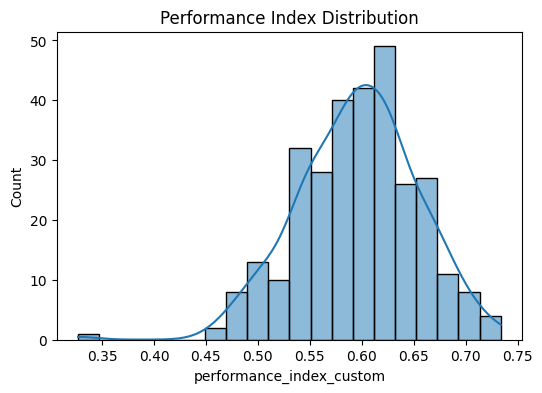


--- Actual Risk (%) ---
risk_flag
Average      62.790698
High Risk    37.209302
Name: proportion, dtype: float64

--- Predicted Risk (Random Forest) (%) ---
predicted_risk_rf
Average      62.458472
High Risk    37.541528
Name: proportion, dtype: float64


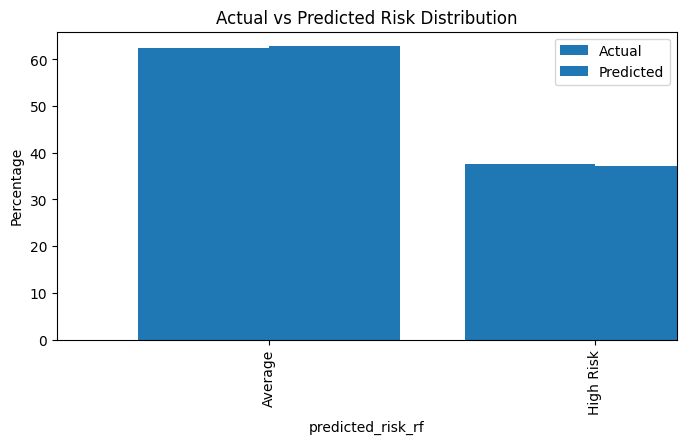

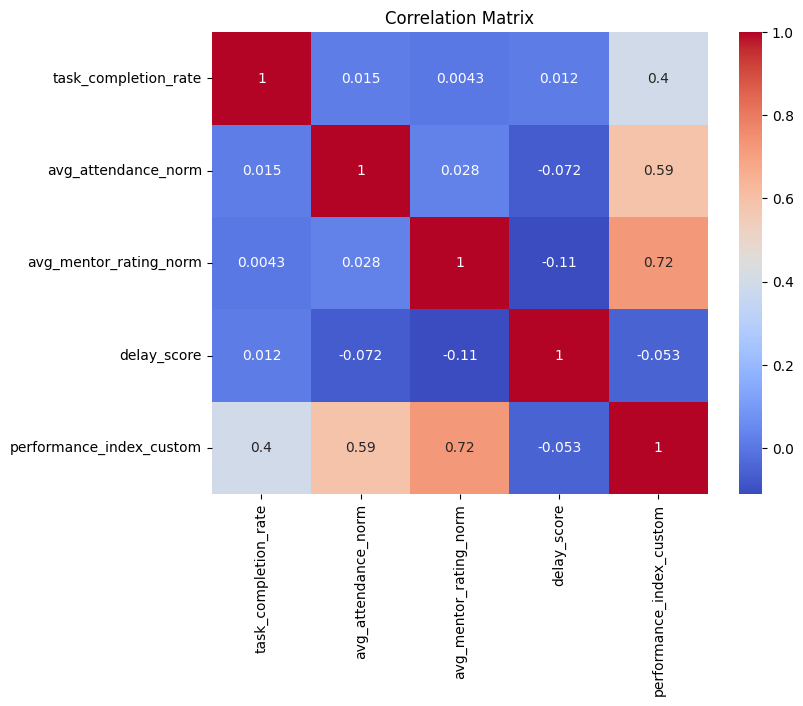


--- Domain-wise Average Performance ---
domain
AI                   0.595965
App Development      0.612721
Cloud Computing      0.600244
Cyber Security       0.581822
Data Science         0.597042
Digital Marketing    0.591404
Java Developer       0.577365
Python Developer     0.605402
UI/UX                0.587793
Web Developer        0.603720
Name: performance_index_custom, dtype: float64


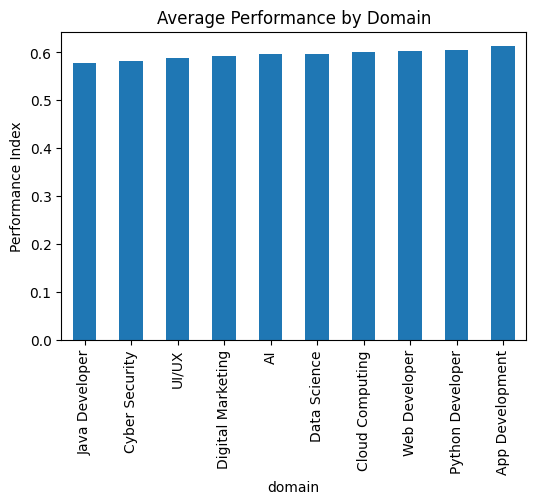


--- Cluster Summary ---
                performance_index_custom  task_completion_rate  \
cluster_label                                                    
At Risk                         0.572114              0.626695   
Average                         0.604494              0.629141   
High Performer                  0.605133              0.707821   

                avg_attendance_norm  avg_mentor_rating_norm  
cluster_label                                                
At Risk                    0.648794                0.508970  
Average                    0.565865                0.734185  
High Performer             0.591750                0.583209  


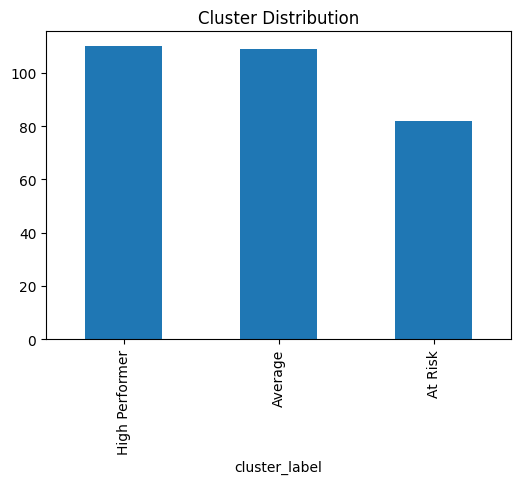

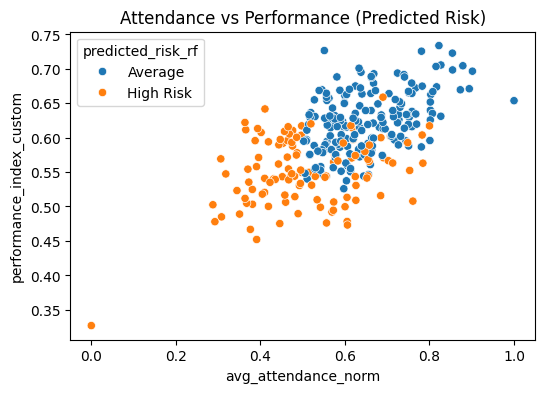


--- Random Forest Accuracy on Full Data ---
Accuracy: 0.997

================ BUSINESS INSIGHTS ================
Average Performance Index: 0.596
Top Influencing Feature: avg_mentor_rating_norm
High Risk Intern Count: 113
High Performer Count: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Final Analysis Phase Completed Successfully


In [7]:
# =====================================================
# INTERN PERFORMANCE DASHBOARD - ANALYSIS PHASE (FINAL)
# =====================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
import os

# -----------------------------------------------------
# 1. UPLOAD IMPROVED ML DATA (COLAB)
# -----------------------------------------------------

uploaded = files.upload()   # Upload final_ml_ready_data_improved.csv
csv_filename = list(uploaded.keys())[0]

print("Uploaded file:", csv_filename)

df = pd.read_csv(csv_filename)

print("Dataset Shape:", df.shape)
print(df.head())


# =====================================================
# 2. PERFORMANCE DISTRIBUTION ANALYSIS
# =====================================================

print("\n--- Performance Index Summary ---")
print(df["performance_index_custom"].describe())

plt.figure(figsize=(6,4))
sns.histplot(df["performance_index_custom"], bins=20, kde=True)
plt.title("Performance Index Distribution")
plt.show()


# =====================================================
# 3. RISK SEGMENTATION COMPARISON (ACTUAL vs PREDICTED)
# =====================================================

actual_risk = df["risk_flag"].value_counts(normalize=True) * 100
predicted_risk = df["predicted_risk_rf"].value_counts(normalize=True) * 100

print("\n--- Actual Risk (%) ---")
print(actual_risk)

print("\n--- Predicted Risk (Random Forest) (%) ---")
print(predicted_risk)

plt.figure(figsize=(8,4))
actual_risk.plot(kind="bar", position=0, width=0.4, label="Actual")
predicted_risk.plot(kind="bar", position=1, width=0.4, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Risk Distribution")
plt.ylabel("Percentage")
plt.show()


# =====================================================
# 4. CORRELATION ANALYSIS
# =====================================================

features_corr = [
    "task_completion_rate",
    "avg_attendance_norm",
    "avg_mentor_rating_norm",
    "delay_score",
    "performance_index_custom"
]

plt.figure(figsize=(8,6))
sns.heatmap(df[features_corr].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# =====================================================
# 5. DOMAIN-WISE PERFORMANCE ANALYSIS
# =====================================================

if "domain" in df.columns:
    domain_perf = df.groupby("domain")["performance_index_custom"].mean()

    print("\n--- Domain-wise Average Performance ---")
    print(domain_perf)

    plt.figure(figsize=(6,4))
    domain_perf.sort_values().plot(kind="bar")
    plt.title("Average Performance by Domain")
    plt.ylabel("Performance Index")
    plt.show()
else:
    print("\nDomain column not found. Skipping domain analysis.")


# =====================================================
# 6. CLUSTER ANALYSIS
# =====================================================

if "cluster_label" in df.columns:

    cluster_summary = df.groupby("cluster_label").mean(numeric_only=True)

    print("\n--- Cluster Summary ---")
    print(cluster_summary[[
        "performance_index_custom",
        "task_completion_rate",
        "avg_attendance_norm",
        "avg_mentor_rating_norm"
    ]])

    plt.figure(figsize=(6,4))
    df["cluster_label"].value_counts().plot(kind="bar")
    plt.title("Cluster Distribution")
    plt.show()

else:
    print("\nCluster label not found.")


# =====================================================
# 7. ATTENDANCE VS PERFORMANCE (PREDICTED RISK)
# =====================================================

plt.figure(figsize=(6,4))
sns.scatterplot(
    x="avg_attendance_norm",
    y="performance_index_custom",
    hue="predicted_risk_rf",
    data=df
)
plt.title("Attendance vs Performance (Predicted Risk)")
plt.show()


# =====================================================
# 8. MODEL PERFORMANCE SUMMARY
# =====================================================

rf_accuracy = np.mean(
    df["predicted_risk_rf"] == df["risk_flag"]
)

print("\n--- Random Forest Accuracy on Full Data ---")
print("Accuracy:", round(rf_accuracy, 3))


# =====================================================
# 9. BUSINESS INSIGHTS SUMMARY
# =====================================================

print("\n================ BUSINESS INSIGHTS ================")

print("Average Performance Index:",
      round(df["performance_index_custom"].mean(), 3))

print("Top Influencing Feature:",
      df[features_corr].corr()["performance_index_custom"]
        .drop("performance_index_custom")
        .abs()
        .idxmax())

print("High Risk Intern Count:",
      df[df["predicted_risk_rf"]=="High Risk"].shape[0])

print("High Performer Count:",
      df[df["predicted_risk_rf"]=="High Performer"].shape[0])

print("===================================================")


# =====================================================
# 10. SAVE FINAL ANALYSIS SUMMARY
# =====================================================

summary_dict = {
    "Average_Performance_Index":
        df["performance_index_custom"].mean(),

    "High_Risk_Count_Predicted":
        df[df["predicted_risk_rf"]=="High Risk"].shape[0],

    "High_Performer_Count_Predicted":
        df[df["predicted_risk_rf"]=="High Performer"].shape[0],

    "Random_Forest_Accuracy":
        rf_accuracy
}

summary_df = pd.DataFrame([summary_dict])

output_file = "analysis_summary_improved.csv"
summary_df.to_csv(output_file, index=False)

files.download(output_file)

print("\n✅ Final Analysis Phase Completed Successfully")